# Archetype Profiles

Interpret the archetypes by looking at:

- The mean feature vector per archetype (heatmap)
- The within-event-type cluster mix per archetype
- A few example players per archetype

Use this notebook to give each archetype a human-readable name
(e.g. *CD-2 = ball-playing center-back*).

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

# locate repo root from the notebook's location
HERE = Path.cwd()
ROOT = HERE
while ROOT != ROOT.parent and not (ROOT / "configs" / "config.yaml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

CFG = yaml.safe_load((ROOT / "configs" / "config.yaml").read_text())
ART = ROOT / CFG["data_paths"]["archetype_artifacts"]
EVENT_MODEL_DIR = ART / "event_clusters"
ARCH_MODEL_DIR = ART / "archetype_clusters"

EVENT_TYPES_PER_GROUP = CFG["event_clustering"]["event_types_per_group"]
N_CLUSTERS_PER_EVENT = CFG["event_clustering"]["n_clusters_per_event"]
N_ARCHETYPES_PER_GROUP = CFG["archetype_clustering"]["n_archetypes_per_group"]
POSITION_GROUPS = list(EVENT_TYPES_PER_GROUP.keys())

print("ROOT:", ROOT)
print("ART :", ART)

ROOT: c:\Users\zcoch\dsc_148\DSC 148 Final Project
ART : c:\Users\zcoch\dsc_148\DSC 148 Final Project\data\processed\archetype_artifacts


In [2]:
from archetypes.player_aggregation import feature_columns_for_group

feats = pd.read_parquet(ART / "player_features.parquet")
amap  = pd.read_parquet(ART / "player_archetype_map.parquet")
df = feats.merge(amap[["player_id", "season", "archetype"]], on=["player_id", "season"])
player_info = pd.read_parquet(ROOT / "data" / "raw" / "player_info.parquet")
player_info = player_info.rename(columns={"wyId": "player_id"})
df = df.merge(player_info[["player_id", "shortName"]], on="player_id", how="left")
print(df.shape)
df.head()

(15262, 52)


,player_id,season,position_group,player_position,pct_total_pass,pct_cluster_pass_0,pct_cluster_pass_1,pct_cluster_pass_2,pct_cluster_pass_3,pct_cluster_pass_4,...,pct_cluster_offensive_duel_5,pct_cluster_aerial_duel_5,pct_cluster_shot_5,pct_cluster_shot_6,pct_total_goalkeeper_exit,pct_cluster_goalkeeper_exit_0,pct_cluster_goalkeeper_exit_1,pct_cluster_goalkeeper_exit_2,archetype,shortName
0,56299,2023,CD,CB,0.809524,0.106262,0.195446,0.028463,0.094877,0.085389,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CD-1,M. Christensen
1,193106,2024,CD,RCB3,0.860784,0.120729,0.006834,0.095672,0.015945,0.150342,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CD-2,G. Quinn
2,218479,2022,CD,RCB,0.592689,0.140969,0.039648,0.118943,0.022026,0.202643,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CD-2,K. Allen
3,251954,2021,CD,RCB,0.774283,0.109916,0.046595,0.065711,0.044205,0.182796,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CD-2,B. O'Hara
4,259995,2021,CD,RCB,0.804622,0.182768,0.112272,0.096606,0.049608,0.109661,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,CD-2,M. Borger


## Heatmap of mean feature values per archetype

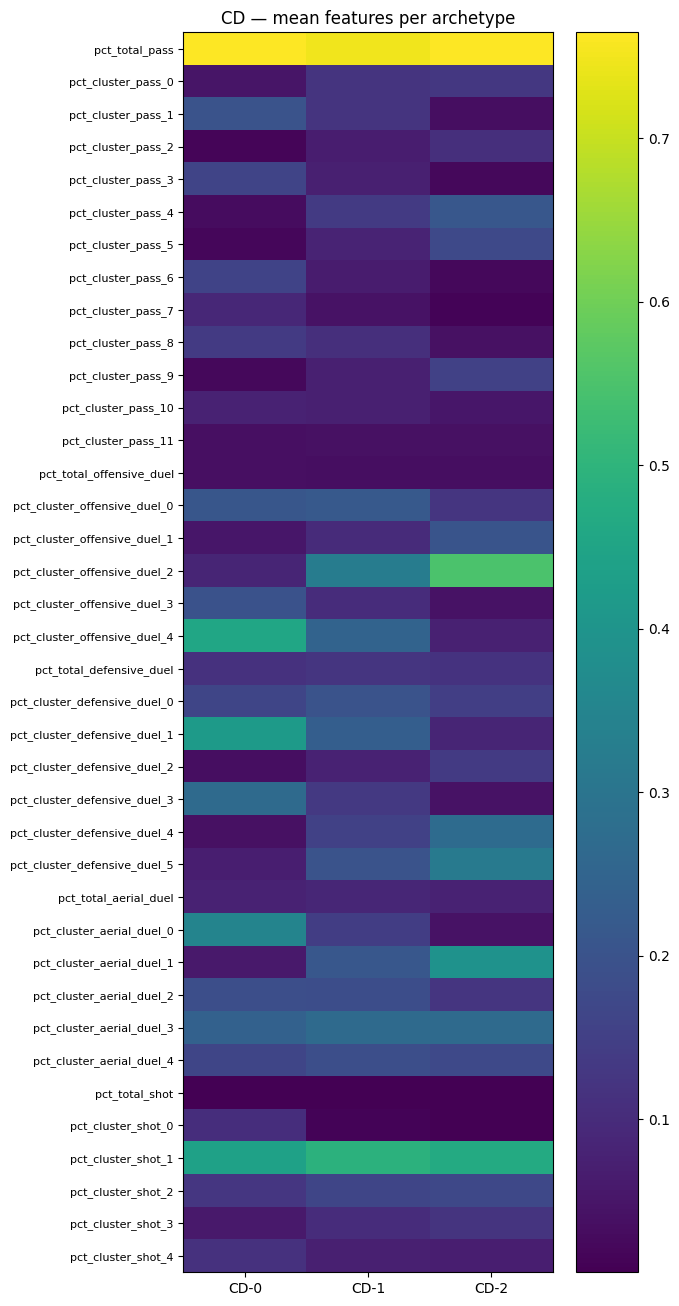

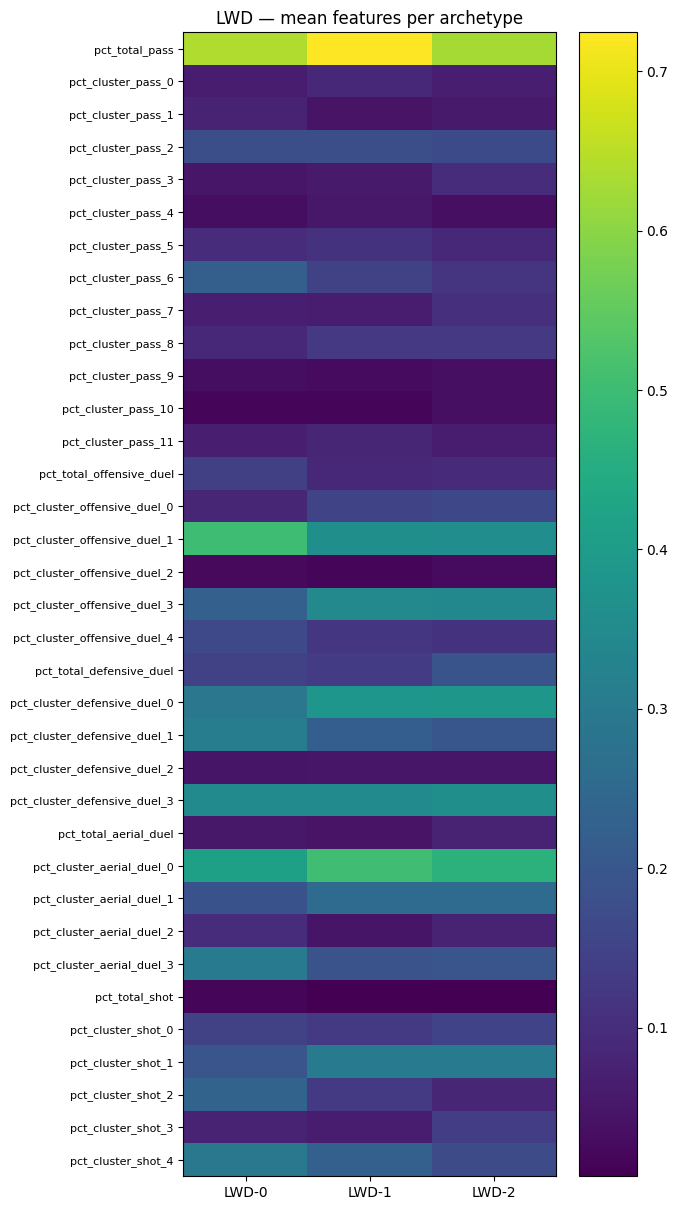

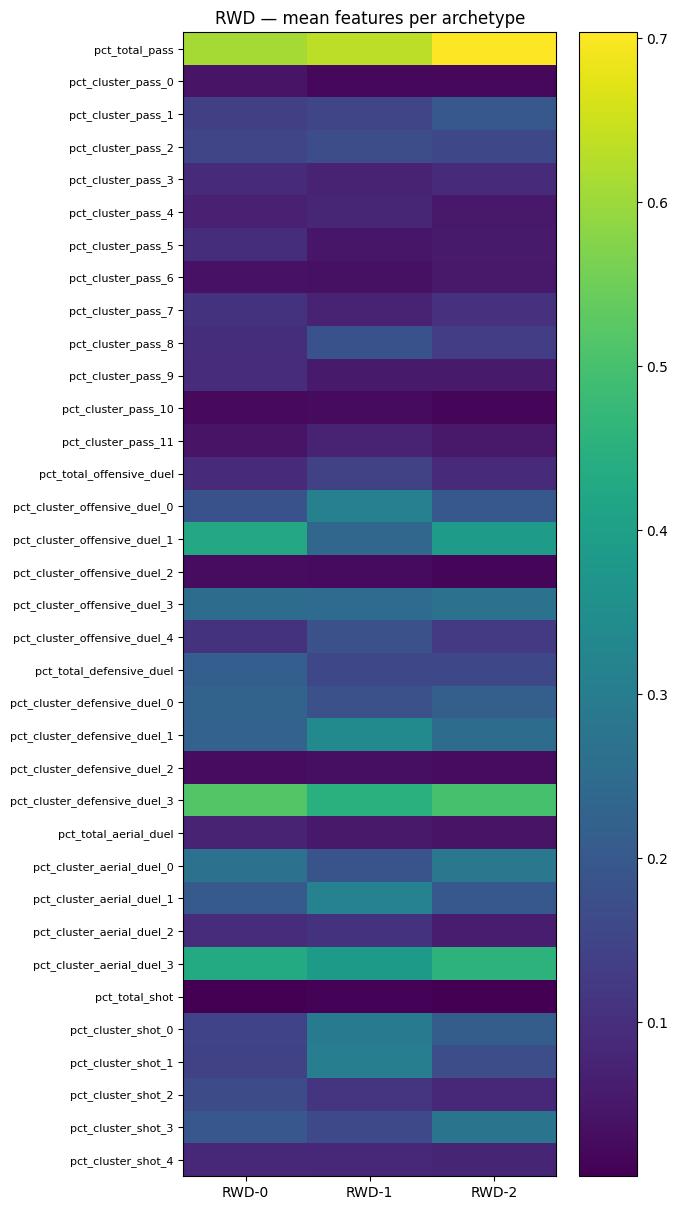

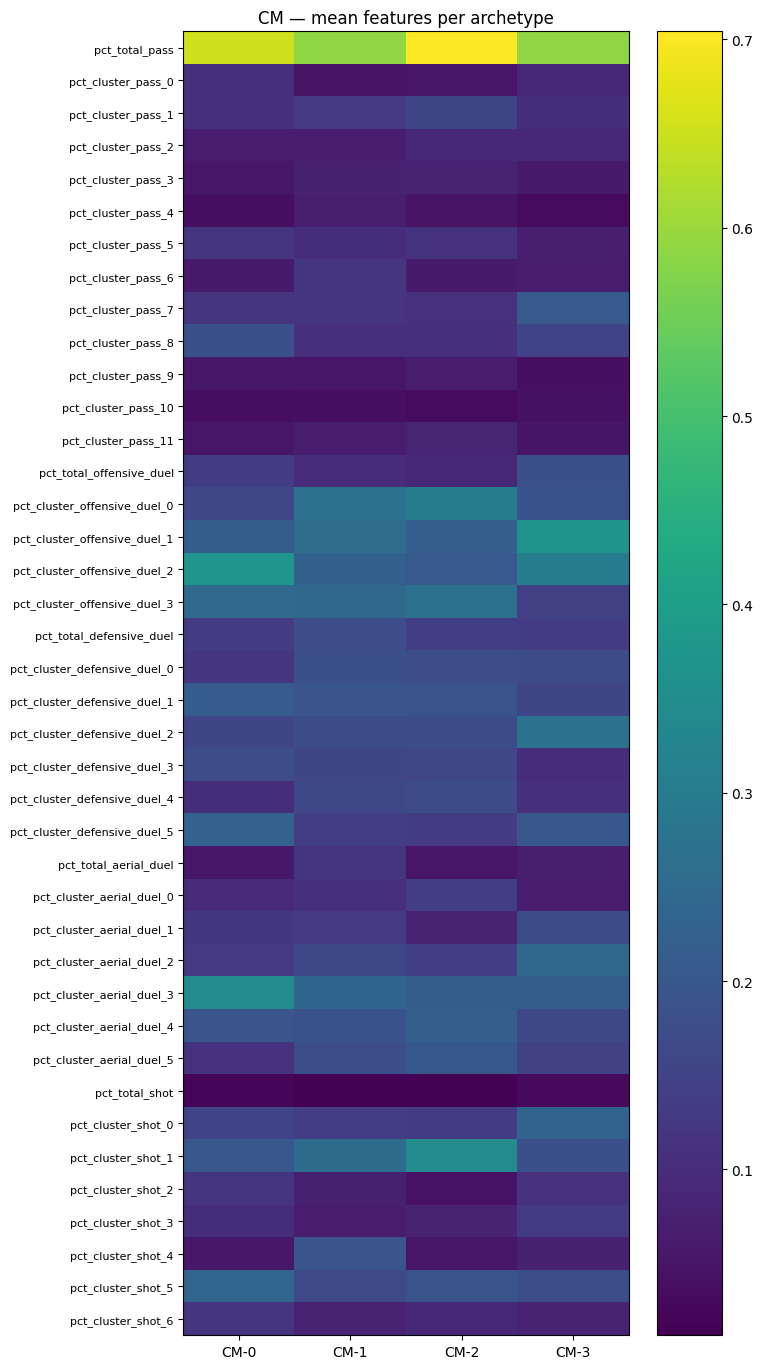

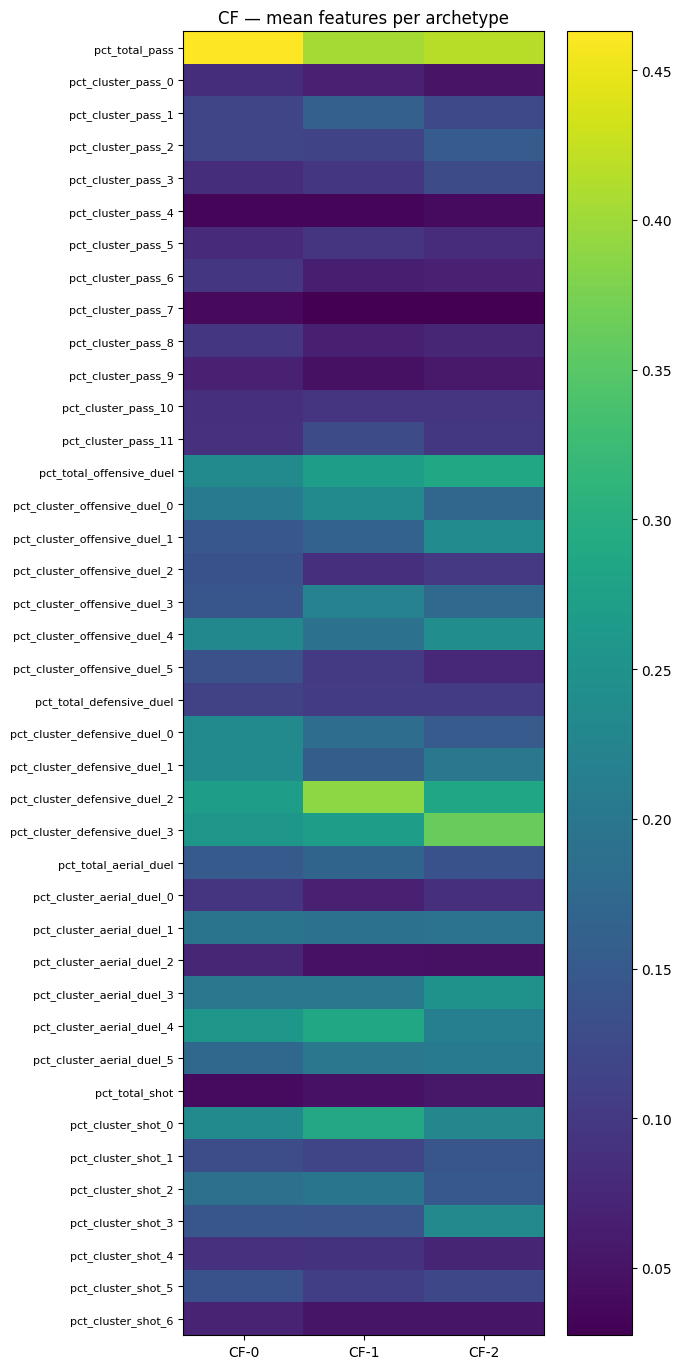

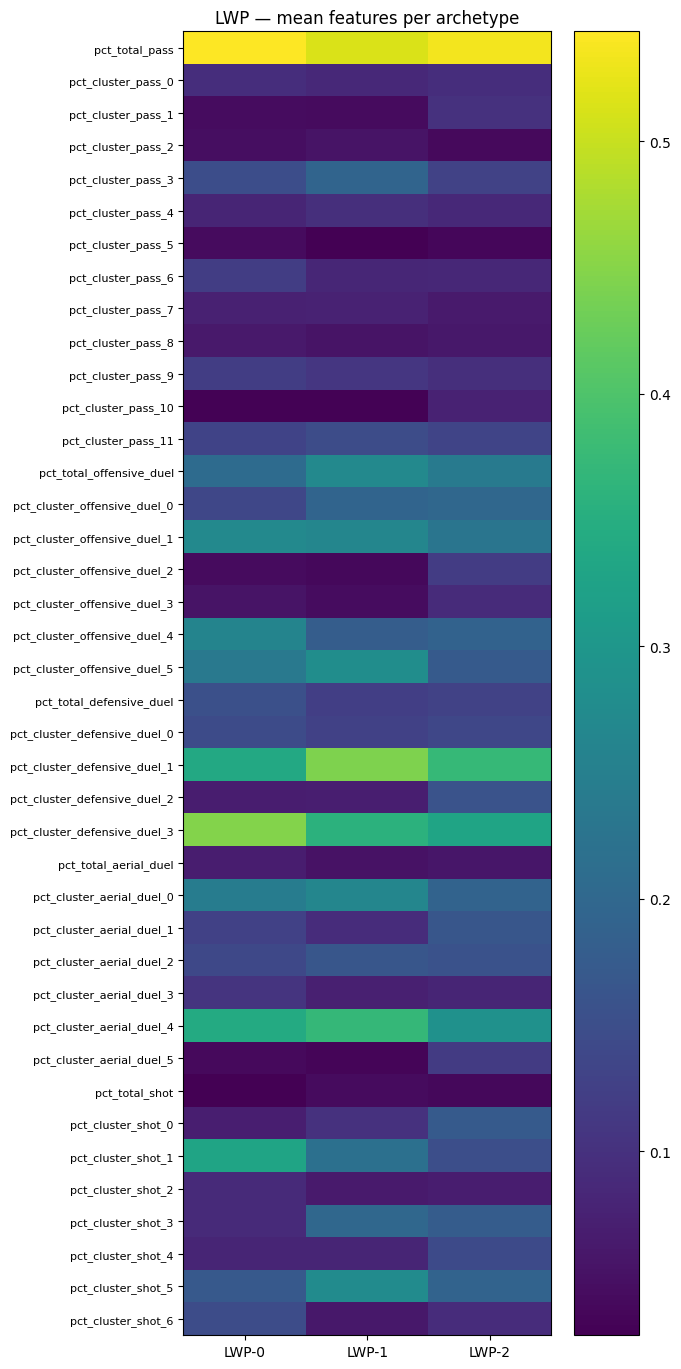

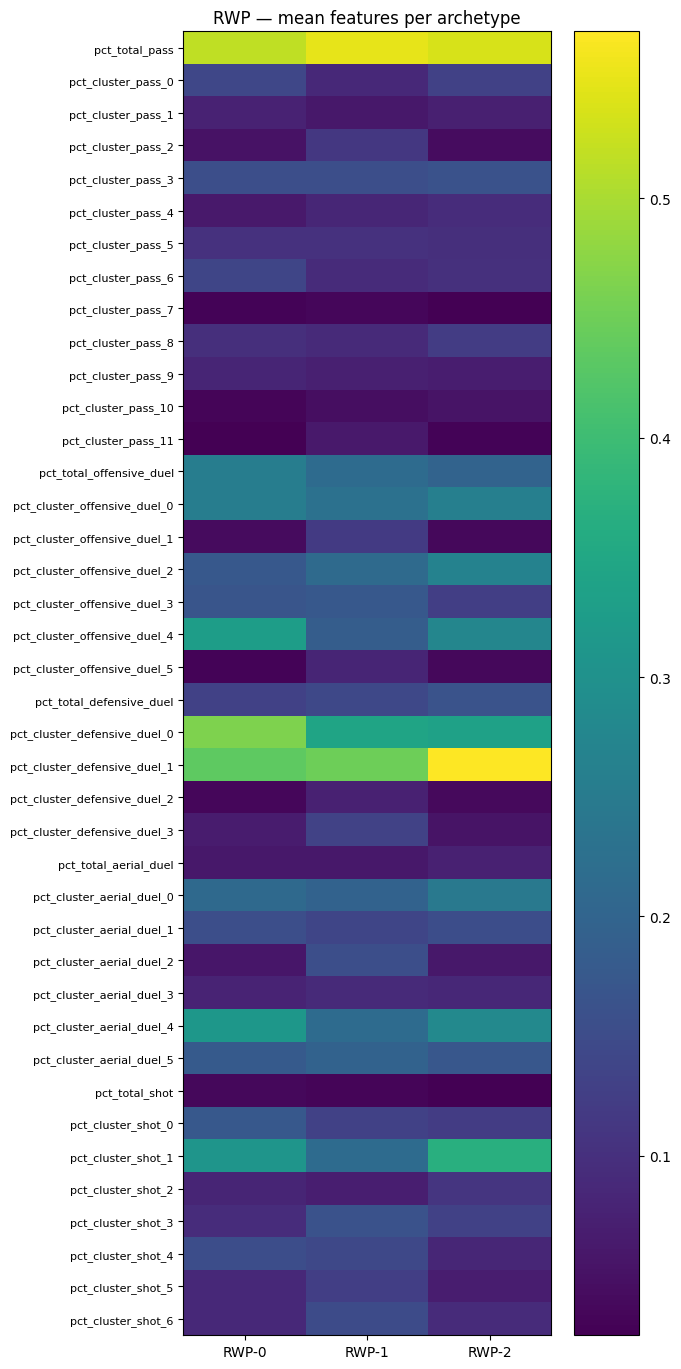

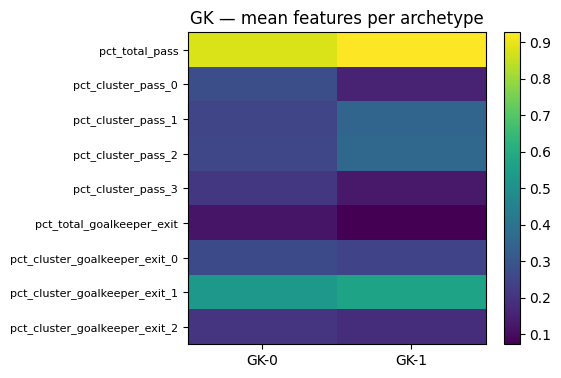

In [3]:
for g in POSITION_GROUPS:
    cols = feature_columns_for_group(EVENT_TYPES_PER_GROUP[g], N_CLUSTERS_PER_EVENT[g])
    sub = df[df["position_group"] == g]
    prof = sub.groupby("archetype")[cols].mean()
    fig, ax = plt.subplots(figsize=(0.9 * len(prof) + 4, 0.32 * len(cols) + 1))
    im = ax.imshow(prof.T.values, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(prof.index))); ax.set_xticklabels(prof.index)
    ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols, fontsize=8)
    fig.colorbar(im, ax=ax)
    ax.set_title(f"{g} - mean features per archetype")
    plt.tight_layout(); plt.show()

## Within-event-type cluster mix per archetype

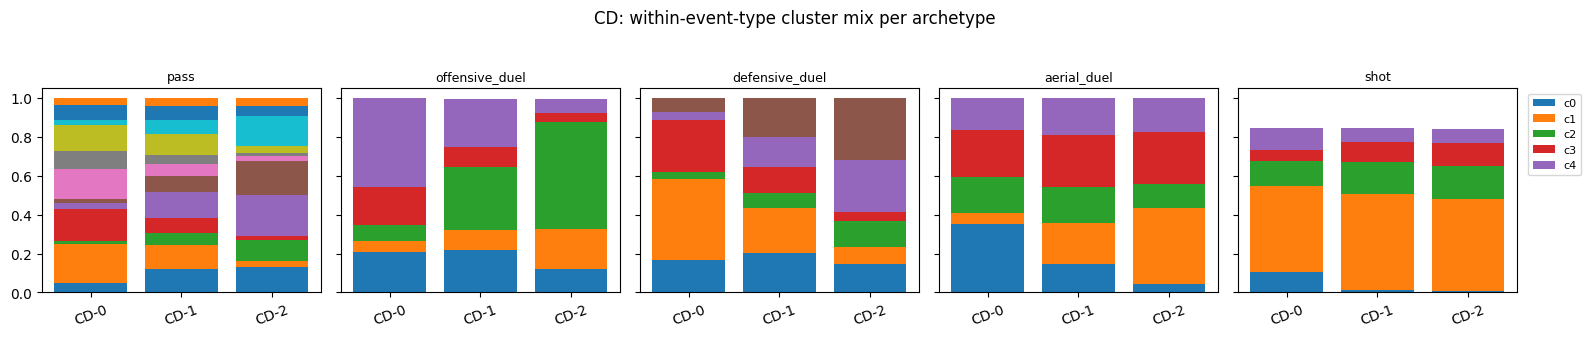

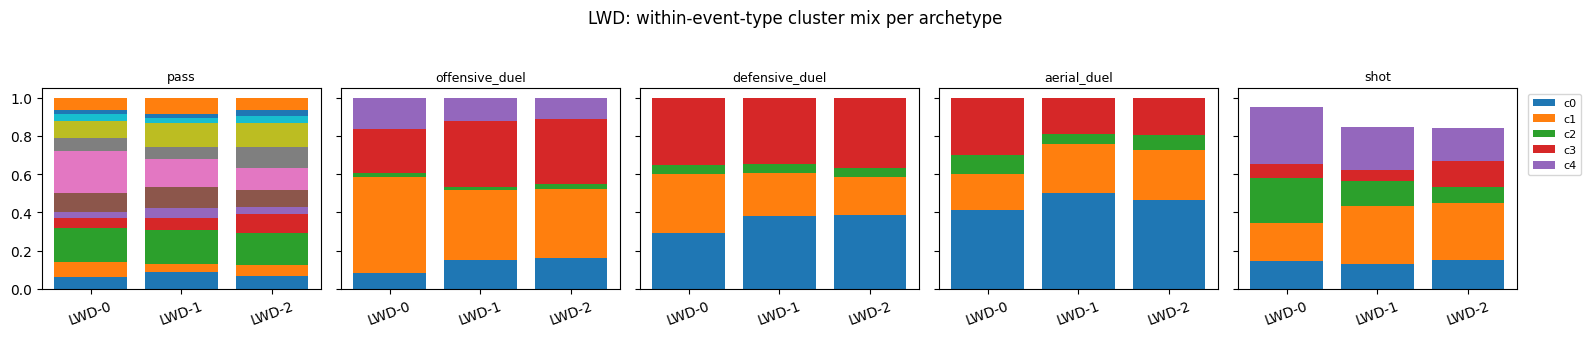

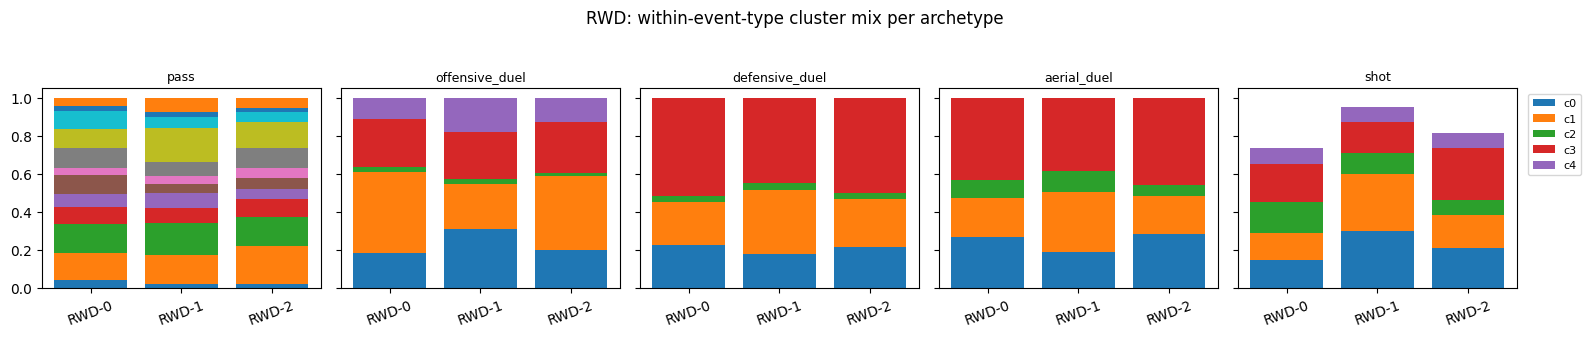

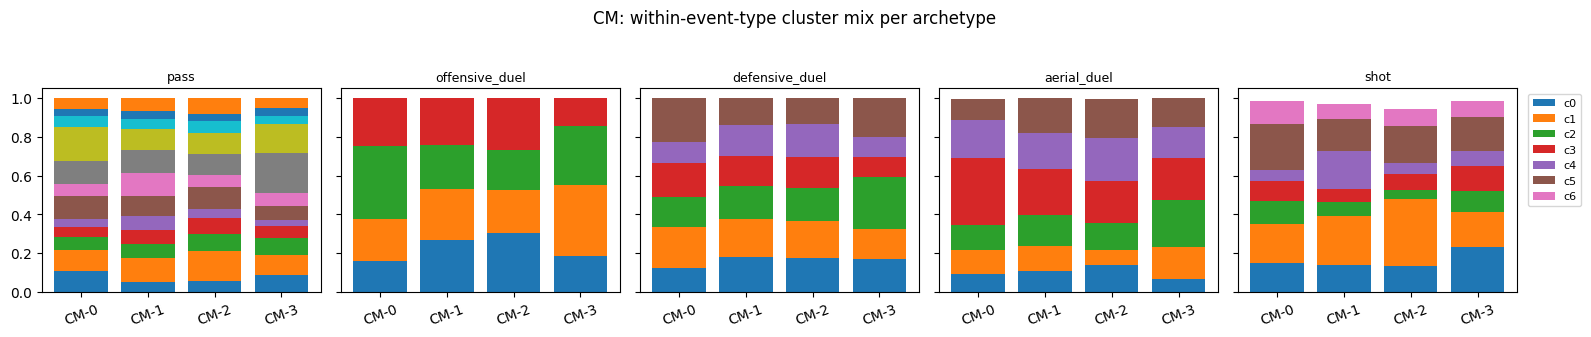

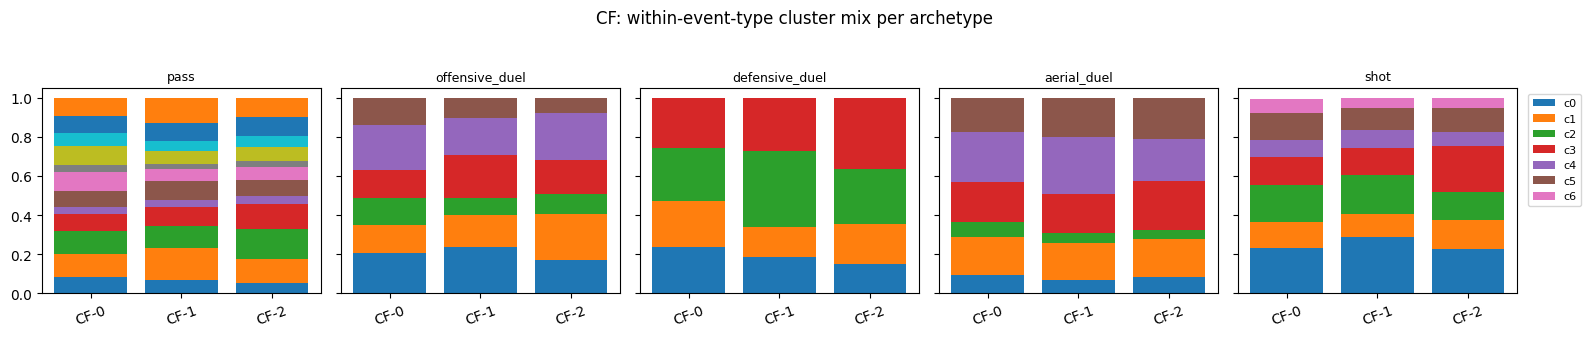

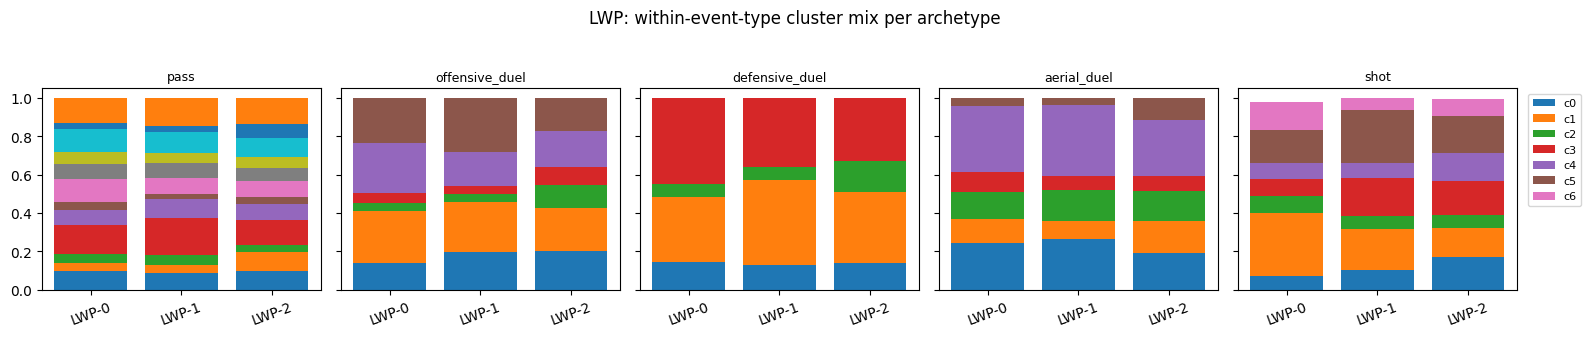

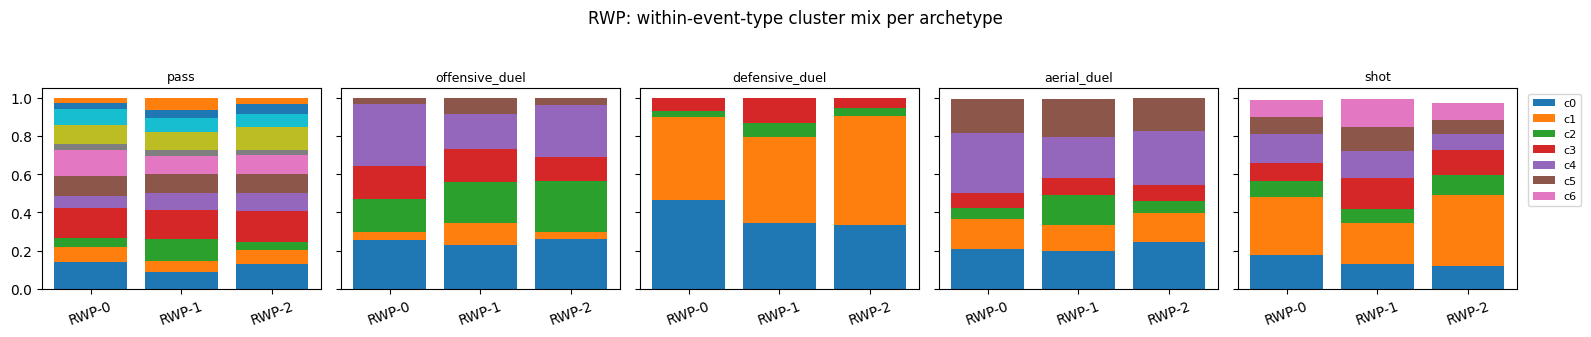

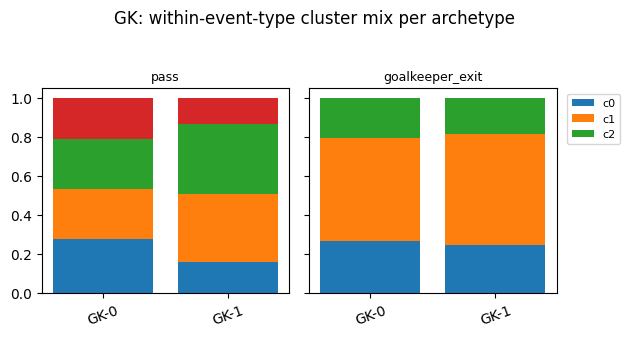

In [5]:
for g in POSITION_GROUPS:
    ets = EVENT_TYPES_PER_GROUP[g]
    sub = df[df["position_group"] == g]
    archetypes = sorted(sub["archetype"].unique())
    fig, axes = plt.subplots(1, len(ets), figsize=(3.2 * len(ets), 3.2), sharey=True)
    if len(ets) == 1:
        axes = [axes]
    for ax, et in zip(axes, ets):
        cols = [f"pct_cluster_{et}_{i}" for i in range(N_CLUSTERS_PER_EVENT[g][et])]
        M = sub.groupby("archetype")[cols].mean().reindex(archetypes)
        bottom = np.zeros(len(M))
        for i, c in enumerate(cols):
            ax.bar(M.index, M[c].values, bottom=bottom,
                   label=f"c{i}")
            bottom = bottom + M[c].values
        ax.set_title(et, fontsize=9)
        ax.set_ylim(0, 1.05)
        ax.tick_params(axis="x", rotation=20)
    axes[-1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    fig.suptitle(f"{g}: within-event-type cluster mix per archetype", y=1.04)
    fig.tight_layout(); plt.show()

## Example players per archetype

In [6]:
for g in POSITION_GROUPS:
    sub = df[df["position_group"] == g]
    print(f"=== {g} ===")
    for arch in sorted(sub["archetype"].unique()):
        rows = sub.loc[sub["archetype"] == arch, ["shortName", "season"]].dropna(subset=["shortName"])
        picks = rows.sample(min(8, len(rows)), random_state=0)
        labels = [f"{n} ({s})" for n, s in zip(picks["shortName"], picks["season"])]
        print(f"  {arch}: " + ", ".join(labels))
    print()

=== CD ===
  CD-0: A. Lara (2021), M. Mamut (2021), T. Timchenko (2022), E. Le (2022), P. Amponsah (2020), B. Griffin (2024), J. Rippon (2023), H. Le Guennec (2021)
  CD-1: J. Kim (2022), J. Hsieh-Bailey (2023), A. Crabtree (2021), A. Fofana (2024), A. Smith (2021), G. Easton (2024), W. Stinson (2024), W. Nilsson (2024)
  CD-2: N. Miller (2023), T. Fillaudeau (2022), R. Cederberg (2021), G. Carmichael (2024), L. Rodrigues (2021), K. Kendall (2021), G. Easton (2021), T. Gray (2024)

=== LWD ===
  LWD-0: T. Johnson (2024), L. Bosc (2024), K. Tingey (2022), A. Patti (2022), A. Francois (2021), J. Andersson (2024), B.Swinehart (2022), T. Kirunda (2021)
  LWD-1: O. Sullivan (2024), G. Rosengren (2024), J. Cromer (2023), E. Cook (2023), M. Henderson (2023), M. Bleeker (2022), A. Zielonka (2024), Z. Sauer (2024)
  LWD-2: N. Boyce (2022), P. Roditti (2023), N. Haddad (2023), J. Sluys (2021), O. Baudey (2022), A. Zaffino (2022), B. Golden (2021),  I. Obeid (2022)

=== RWD ===
  RWD-0: B. Pope (